# EdgeVision: Accuracy vs. Efficiency in Small CNNs

**Question:** How much accuracy can a vision model retain when its size and CPU cost are reduced?

Run the baseline first, then change one variable and interpret your own results.

In [ ]:
!pip -q install torch torchvision matplotlib numpy

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving EdgeVision_Veritas_Project.zip to EdgeVision_Veritas_Project.zip


In [ ]:
!unzip -o EdgeVision_Veritas_Project.zip

Archive:  EdgeVision_Veritas_Project.zip
  inflating: edgevision_project/train.py  
  inflating: edgevision_project/benchmark.py  
  inflating: edgevision_project/research_log.md  
  inflating: edgevision_project/requirements.txt  
  inflating: edgevision_project/colab_notes.md  
  inflating: edgevision_project/EdgeVision_Colab.ipynb  
  inflating: edgevision_project/README.md  


In [ ]:
%cd /content/edgevision_project

/content/edgevision_project


In [ ]:
!pip install -q -r requirements.txt

In [ ]:
# Copy the project files into the Colab working directory before running this cell.
# Example if you uploaded the files: make sure train.py and benchmark.py are visible in /content.
!python train.py --epochs 2 --train-subset 5000 --test-subset 1000

100% 170M/170M [22:14<00:00, 128kB/s]

=== SmallCNN ===
epoch 1/2: loss=2.1241
epoch 2/2: loss=1.9066
accuracy=29.40% | params=75,754 | size=0.293 MB | CPU=1.163 ms/image

=== TinyCNN ===
epoch 1/2: loss=2.2320
epoch 2/2: loss=2.0697
accuracy=25.90% | params=4,178 | size=0.019 MB | CPU=0.560 ms/image

Saved results to results/metrics.json


In [ ]:
!python benchmark.py

Saved chart to results/comparison.png

Model comparison
SmallCNN: accuracy=29.40% | latency=1.163 ms | params=75,754 | size=0.293 MB
TinyCNN: accuracy=25.90% | latency=0.560 ms | params=4,178 | size=0.019 MB


In [ ]:
import json
from pathlib import Path
data = json.loads(Path('results/metrics.json').read_text())
for row in data['results']:
    print(row['model'], row['accuracy_percent'], row['trainable_parameters'], row['model_size_mb'], row['cpu_latency_ms_per_image'])

SmallCNN 29.4 75754 0.29256725311279297 1.16348941999604
TinyCNN 25.9 4178 0.01869678497314453 0.5597786999987875


## Next experiment

Change exactly one variable. Good choices: number of training examples, number of epochs, or channel counts in the models.

Then answer: Did the change improve accuracy? What happened to model size or latency? What trade-off did you observe?

In [ ]:
%%writefile experiment2.py

from train import Config, set_seed, make_loaders, run_model
from torch import nn


class NanoCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 8, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(8, 12, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d((1, 1)),
        )

        self.classifier = nn.Linear(12, 10)

    def forward(self, x):
        x = self.features(x)
        x = x.flatten(1)
        return self.classifier(x)


cfg = Config(
    epochs=2,
    batch_size=64,
    lr=1e-3,
    train_subset=5000,
    test_subset=1000,
    results_dir="results_exp2",
)

set_seed(cfg.seed)

train_loader, test_loader = make_loaders(cfg)

result = run_model(
    "NanoCNN",
    NanoCNN(),
    train_loader,
    test_loader,
    cfg
)

print("\n=== Experiment 2 complete ===")
print(result)

Writing experiment2.py


In [ ]:
!python experiment2.py


=== NanoCNN ===
epoch 1/2: loss=2.2970
epoch 2/2: loss=2.1812
accuracy=24.90% | params=1,230 | size=0.008 MB | CPU=0.298 ms/image

=== Experiment 2 complete ===
{'model': 'NanoCNN', 'accuracy_percent': 24.9, 'trainable_parameters': 1230, 'model_size_mb': 0.007527351379394531, 'cpu_latency_ms_per_image': 0.297872200007987, 'epoch_losses': [2.2969604972839357, 2.1812180572509767]}


### **Experiment 3**

In [ ]:
%%writefile experiment3.py

from train import Config, set_seed, make_loaders, run_model, SmallCNN, TinyCNN
from torch import nn


class NanoCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 8, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(8, 12, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d((1, 1)),
        )

        self.classifier = nn.Linear(12, 10)

    def forward(self, x):
        x = self.features(x)
        x = x.flatten(1)
        return self.classifier(x)


cfg = Config(
    epochs=5,
    batch_size=64,
    lr=1e-3,
    train_subset=5000,
    test_subset=1000,
    results_dir="results_exp3",
)

set_seed(cfg.seed)

train_loader, test_loader = make_loaders(cfg)

models = [
    ("SmallCNN", SmallCNN()),
    ("TinyCNN", TinyCNN()),
    ("NanoCNN", NanoCNN()),
]

results = []

for name, model in models:
    result = run_model(
        name,
        model,
        train_loader,
        test_loader,
        cfg
    )
    results.append(result)

print("\n=== Experiment 3 summary ===")

for r in results:
    print(
        f"{r['model']}: "
        f"accuracy={r['accuracy_percent']:.2f}% | "
        f"params={r['trainable_parameters']:,} | "
        f"size={r['model_size_mb']:.3f} MB | "
        f"CPU={r['cpu_latency_ms_per_image']:.3f} ms/image"
    )

Writing experiment3.py


In [ ]:
!python experiment3.py


=== SmallCNN ===
epoch 1/5: loss=2.1151
epoch 2/5: loss=1.9260
epoch 3/5: loss=1.8105
epoch 4/5: loss=1.7308
epoch 5/5: loss=1.6688
accuracy=40.70% | params=75,754 | size=0.293 MB | CPU=1.252 ms/image

=== TinyCNN ===
epoch 1/5: loss=2.2101
epoch 2/5: loss=2.0763
epoch 3/5: loss=2.0267
epoch 4/5: loss=1.9842
epoch 5/5: loss=1.9408
accuracy=30.20% | params=4,178 | size=0.019 MB | CPU=0.475 ms/image

=== NanoCNN ===
epoch 1/5: loss=2.2528
epoch 2/5: loss=2.1284
epoch 3/5: loss=2.0536
epoch 4/5: loss=2.0186
epoch 5/5: loss=1.9939
accuracy=26.80% | params=1,230 | size=0.008 MB | CPU=0.310 ms/image

=== Experiment 3 summary ===
SmallCNN: accuracy=40.70% | params=75,754 | size=0.293 MB | CPU=1.252 ms/image
TinyCNN: accuracy=30.20% | params=4,178 | size=0.019 MB | CPU=0.475 ms/image
NanoCNN: accuracy=26.80% | params=1,230 | size=0.008 MB | CPU=0.310 ms/image


## Admissions-ready evidence

After you have genuinely run and understood the experiment, keep: (1) code, (2) results, (3) a chart, (4) research notes, and (5) a short reflection explaining one surprising result or limitation.

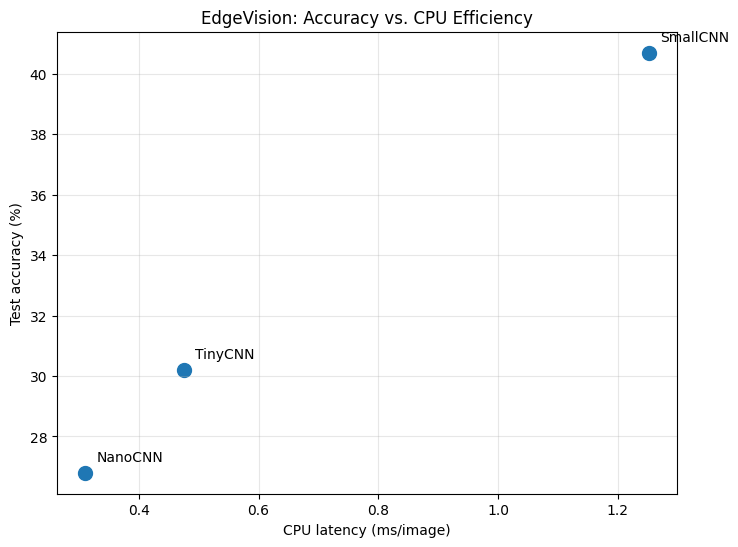

In [ ]:
import matplotlib.pyplot as plt

# Your actual Experiment 3 results
models = ["SmallCNN", "TinyCNN", "NanoCNN"]
accuracy = [40.70, 30.20, 26.80]
parameters = [75754, 4178, 1230]
latency = [1.252, 0.475, 0.310]
model_size = [0.293, 0.019, 0.008]

plt.figure(figsize=(8, 6))

plt.scatter(latency, accuracy, s=100)

for i, model in enumerate(models):
    plt.annotate(
        model,
        (latency[i], accuracy[i]),
        xytext=(8, 8),
        textcoords="offset points"
    )

plt.xlabel("CPU latency (ms/image)")
plt.ylabel("Test accuracy (%)")
plt.title("EdgeVision: Accuracy vs. CPU Efficiency")
plt.grid(True, alpha=0.3)
plt.show()

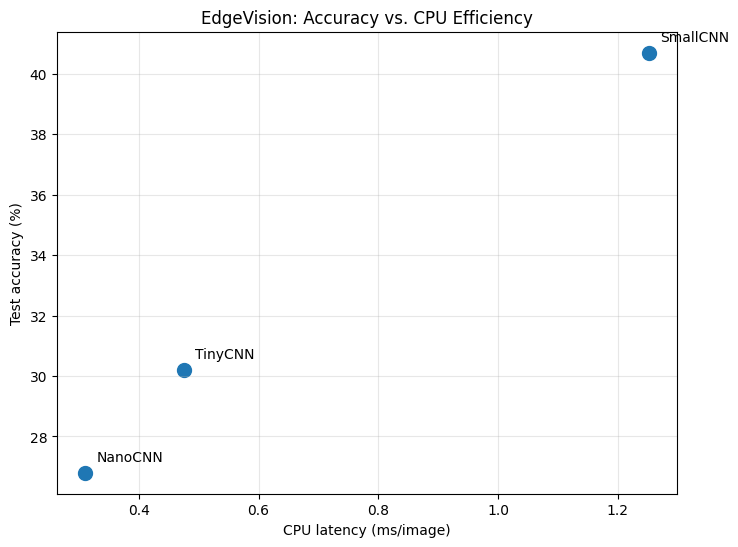

In [ ]:
import matplotlib.pyplot as plt

# Your actual Experiment 3 results
models = ["SmallCNN", "TinyCNN", "NanoCNN"]
accuracy = [40.70, 30.20, 26.80]
parameters = [75754, 4178, 1230]
latency = [1.252, 0.475, 0.310]
model_size = [0.293, 0.019, 0.008]

plt.figure(figsize=(8, 6))

plt.scatter(latency, accuracy, s=100)

for i, model in enumerate(models):
    plt.annotate(
        model,
        (latency[i], accuracy[i]),
        xytext=(8, 8),
        textcoords="offset points"
    )

plt.xlabel("CPU latency (ms/image)")
plt.ylabel("Test accuracy (%)")
plt.title("EdgeVision: Accuracy vs. CPU Efficiency")
plt.grid(True, alpha=0.3)
plt.show()

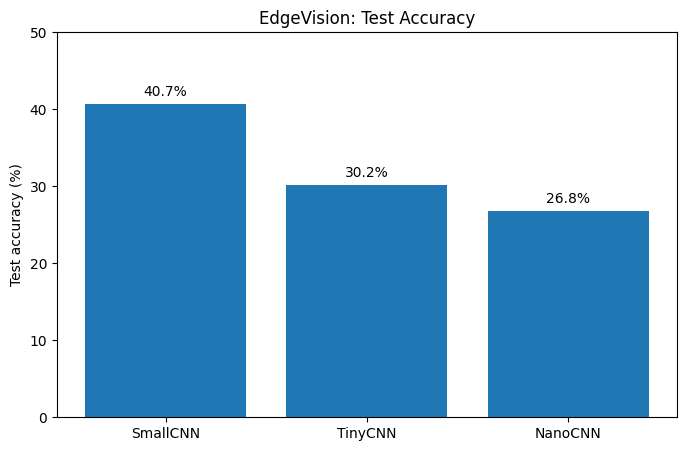

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(models, accuracy)

plt.ylabel("Test accuracy (%)")
plt.title("EdgeVision: Test Accuracy")
plt.ylim(0, 50)

for i, value in enumerate(accuracy):
    plt.text(i, value + 1, f"{value:.1f}%", ha="center")

plt.show()

In [2]:
%%writefile experiment3_fixed.py

from train import Config, set_seed, make_loaders, run_model, SmallCNN, TinyCNN
from torch import nn
import json
import os


class NanoCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 8, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(8, 12, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d((1, 1)),
        )

        self.classifier = nn.Linear(12, 10)

    def forward(self, x):
        x = self.features(x)
        x = x.flatten(1)
        return self.classifier(x)


cfg = Config(
    epochs=5,
    batch_size=64,
    lr=1e-3,
    train_subset=5000,
    test_subset=1000,
    results_dir="results_exp3",
)

set_seed(cfg.seed)

train_loader, test_loader = make_loaders(cfg)

models = [
    ("SmallCNN", SmallCNN()),
    ("TinyCNN", TinyCNN()),
    ("NanoCNN", NanoCNN()),
]

results = []

for name, model in models:
    result = run_model(
        name,
        model,
        train_loader,
        test_loader,
        cfg
    )
    results.append(result)

os.makedirs("results_exp3", exist_ok=True)

with open("results_exp3/metrics.json", "w") as f:
    json.dump(
        {
            "experiment": "Experiment 3 - 5 Epoch Comparison",
            "config": {
                "epochs": 5,
                "train_subset": 5000,
                "test_subset": 1000,
                "learning_rate": 1e-3
            },
            "results": results
        },
        f,
        indent=2
    )

print("\n=== Experiment 3 summary ===")

for r in results:
    print(
        f"{r['model']}: "
        f"accuracy={r['accuracy_percent']:.2f}% | "
        f"params={r['trainable_parameters']:,} | "
        f"size={r['model_size_mb']:.3f} MB | "
        f"CPU={r['cpu_latency_ms_per_image']:.3f} ms/image"
    )

print("\nSaved to results_exp3/metrics.json")

Writing experiment3_fixed.py


In [3]:
import json
import os

os.makedirs("results_exp3", exist_ok=True)

results = [
    {
        "model": "SmallCNN",
        "accuracy_percent": 40.70,
        "trainable_parameters": 75754,
        "model_size_mb": 0.293,
        "cpu_latency_ms_per_image": 1.252
    },
    {
        "model": "TinyCNN",
        "accuracy_percent": 30.20,
        "trainable_parameters": 4178,
        "model_size_mb": 0.019,
        "cpu_latency_ms_per_image": 0.475
    },
    {
        "model": "NanoCNN",
        "accuracy_percent": 26.80,
        "trainable_parameters": 1230,
        "model_size_mb": 0.008,
        "cpu_latency_ms_per_image": 0.310
    }
]

with open("results_exp3/metrics.json", "w") as f:
    json.dump(results, f, indent=2)

print("Saved results_exp3/metrics.json")

Saved results_exp3/metrics.json


In [4]:
with open("results_exp3/metrics.json", "r") as f:
    data = json.load(f)